# Customer Churn Prediction

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

Data Preparation based on EDA

In [89]:
def datapreparation(filepath):

    df = pd.read_csv(filepath)
    df.drop(["customerID"], inplace = True, axis = 1)

    df.TotalCharges = df.TotalCharges.replace(" ",np.nan)
    df.TotalCharges.fillna(0, inplace = True)
    df.TotalCharges = df.TotalCharges.astype(float)

    cols1 = ['Partner', 'Dependents', 'PaperlessBilling', 'Churn', 'PhoneService']
    for col in cols1:
        df[col] = df[col].apply(lambda x: 0 if x == "No" else 1)

    df.gender = df.gender.apply(lambda x: 0 if x == "Male" else 1)
    df.MultipleLines = df.MultipleLines.map({'No phone service': 0, 'No': 0, 'Yes': 1})

    cols2 = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    for col in cols2:
        df[col] = df[col].map({'No internet service': 0, 'No': 0, 'Yes': 1})

    df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=True)

    return df

In [90]:
df = datapreparation(filepath = "/content/WA_Fn-UseC_-Telco-Customer-Churn (1).csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,0,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,0,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,0,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,1,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


In [94]:
df.isnull().any().any()

np.False_

**Model Building**

I am going to build and tune random forest model because in this case tree based method would perform better. I am also interested in individual customer's churning probability and in understanding how the model calculates it using Shap values.

In [95]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

In [96]:
train, test = train_test_split(df, test_size=0.2, random_state=111, stratify = df.Churn)

In [97]:
x = df.columns[df.columns!="Churn"]
y = "Churn"
train_x = train[x]
train_y = train[y]
test_x = test[x]
test_y = test[y]

In [92]:
#function for model fitting
def churn_prediction(algo, training_x, training_y, testing_x, testing_y, cols, cf = 'coefficients'):
    algo.fit(training_x,training_y)
    predictions = algo.predict(testing_x)
    probabilities = algo.predict_proba(testing_x)[:,1]

    #coeffs
    if cf == "coefficients":
        coefficients = pd.DataFrame(algo.coef_.ravel())
    elif cf == "features":
        coefficients = pd.DataFrame(algo.feature_importances_)

    column_df = pd.DataFrame(cols)
    coef_sumry = (pd.merge(coefficients,column_df,left_index= True,
                              right_index= True, how = "left"))
    coef_sumry.columns = ["coefficients","features"]
    coef_sumry = coef_sumry.sort_values(by = "coefficients",ascending = False)

    print (algo)
    print ("\n Classification report : \n",classification_report(testing_y,predictions))
    print ("Accuracy   Score : ",accuracy_score(testing_y,predictions))

    #confusion matrix
    conf_matrix = confusion_matrix(testing_y,predictions)
    plt.figure(figsize=(12,12))
    plt.subplot(221)
    sns.heatmap(conf_matrix, fmt = "d",annot=True, cmap='Blues')
    plt.title('Confuion Matrix')
    plt.ylabel('True Values')
    plt.xlabel('Predicted Values')

    #roc_auc_score
    model_roc_auc = roc_auc_score(testing_y,probabilities)
    print ("Area under curve : ",model_roc_auc,"\n")
    fpr,tpr,thresholds = roc_curve(testing_y,probabilities)

    plt.subplot(222)
    plt.plot(fpr, tpr, color='darkorange', lw=1, label = "Auc : %.3f" %model_roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic')
    plt.legend(loc="lower right")

    plt.subplot(212)
    sns.barplot(x = coef_sumry["features"] ,y = coef_sumry["coefficients"])
    plt.title('Feature Importances')
    plt.xticks(rotation="vertical")

    plt.show()

**Hyperparameters Tuning**

Grid 1: Selecting class weight and estimators

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid1 = {
    'max_features': ['sqrt', 'log2'],
    'n_estimators': [100, 300]
}

rf_model = RandomForestClassifier(random_state=42)
grid1 = GridSearchCV(estimator=rf_model, param_grid=param_grid1,
                     n_jobs=-1, cv=3, verbose=1, scoring='f1')
grid1.fit(train_x, train_y)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_features': ['sqrt', 'log2'],
                         'n_estimators': [100, 300]},
             scoring='f1', verbose=1)

In [ ]:
grid1.best_estimator_

RandomForestClassifier(n_estimators=300, random_state=42)

<Axes: xlabel='param_max_features', ylabel='param_n_estimators'>

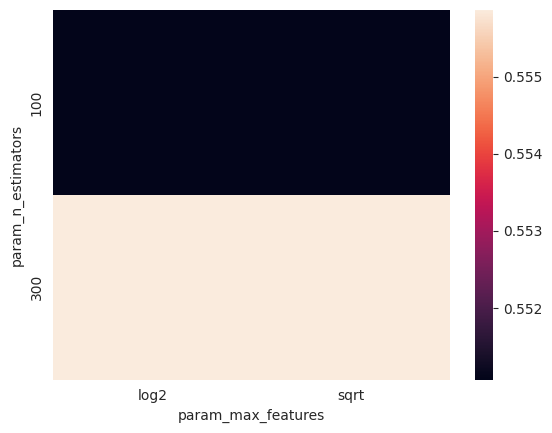

In [ ]:
dt = pd.DataFrame(grid1.cv_results_)
dt.param_max_features = dt.param_max_features.astype(str)
dt.param_n_estimators = dt.param_n_estimators.astype(str)

table = pd.pivot_table(dt, values='mean_test_score', index='param_n_estimators',
                       columns='param_max_features')

sns.heatmap(table)

In [ ]:
grid1.best_score_

np.float64(0.5558659145658305)

Grid 2: Selecting max depth and split criterion

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid2 = {
    'max_features': ['sqrt'],
    'n_estimators': [100, 200],
    'criterion': ['entropy', 'gini'],
    'max_depth': [7, 9, 11, None]
}

rf_model = RandomForestClassifier(random_state=42)
grid2 = GridSearchCV(estimator=rf_model, param_grid=param_grid2,
                     n_jobs=-1, cv=3, verbose=1, scoring='f1')
grid2.fit(train_x, train_y)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['entropy', 'gini'],
                         'max_depth': [7, 9, 11, None],
                         'max_features': ['sqrt'], 'n_estimators': [100, 200]},
             scoring='f1', verbose=1)

In [ ]:
grid2.best_estimator_

RandomForestClassifier(criterion='entropy', max_depth=11, n_estimators=200,
                       random_state=42)

<Axes: xlabel='param_criterion', ylabel='param_max_depth'>

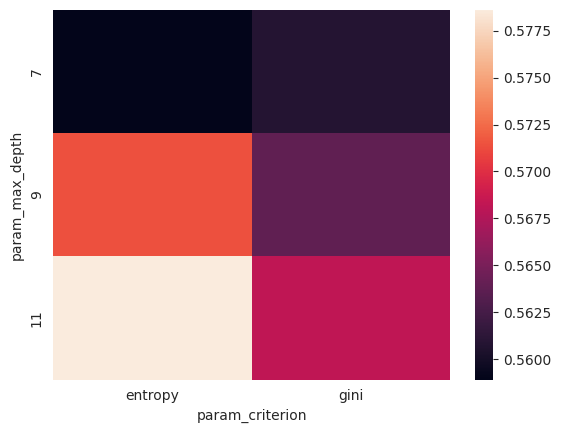

In [ ]:
dt = pd.DataFrame(grid2.cv_results_)

table = pd.pivot_table(dt, values='mean_test_score', index='param_max_depth',
                       columns='param_criterion')

sns.heatmap(table)

<Axes: xlabel='param_n_estimators', ylabel='param_max_depth'>

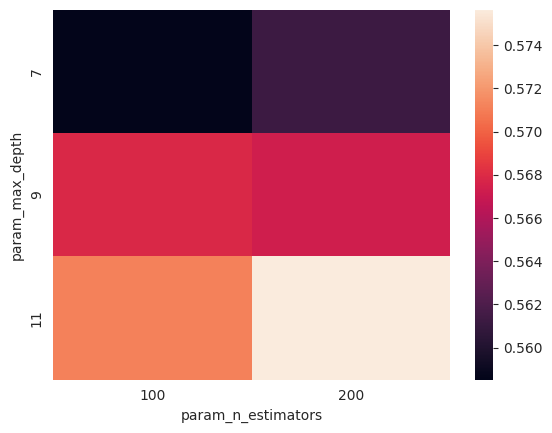

In [ ]:
table = pd.pivot_table(dt, values='mean_test_score', index='param_max_depth',
                       columns='param_n_estimators')

sns.heatmap(table)

In [ ]:
grid2.best_score_

np.float64(0.5802616393854558)

Checking if other depth and estimator value results better

In [98]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid2_2 = {
    'max_features': ['sqrt'],
    'n_estimators': [950, 1000, 1050],
    'criterion': ['entropy'],
    'max_depth': [10, 11, 12]
}

rf_model = RandomForestClassifier(random_state=42)
grid2_2 = GridSearchCV(estimator=rf_model, param_grid=param_grid2_2,
                       n_jobs=-1, cv=3, verbose=1, scoring='f1')
grid2_2.fit(train_x, train_y)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['entropy'], 'max_depth': [10, 11, 12],
                         'max_features': ['sqrt'],
                         'n_estimators': [950, 1000, 1050]},
             scoring='f1', verbose=1)

In [ ]:
grid2_2.best_estimator_

RandomForestClassifier(criterion='entropy', max_depth=11, n_estimators=950,
                       random_state=42)

In [ ]:
grid2_2.best_score_

np.float64(0.5830233491505697)

Grid 3: Selecting minimum samples leaf and split

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid3 = {
    'max_features': ['sqrt'],
    'n_estimators': [1000],
    'criterion': ['entropy'],
    'max_depth': [10],
    'min_samples_leaf': [1, 3, 5, 7],
    'min_samples_split': [2, 4, 6, 8]
}

rf_model = RandomForestClassifier(random_state=42)
grid3 = GridSearchCV(estimator=rf_model, param_grid=param_grid3,
                     n_jobs=-1, cv=3, verbose=1, scoring='f1')
grid3.fit(train_x, train_y)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['entropy'], 'max_depth': [10],
                         'max_features': ['sqrt'],
                         'min_samples_leaf': [1, 3, 5, 7],
                         'min_samples_split': [2, 4, 6, 8],
                         'n_estimators': [1000]},
             scoring='f1', verbose=1)

In [ ]:
grid3.best_estimator_

RandomForestClassifier(criterion='entropy', max_depth=10, min_samples_split=6,
                       n_estimators=1000, random_state=42)

<Axes: xlabel='param_min_samples_split', ylabel='param_min_samples_leaf'>

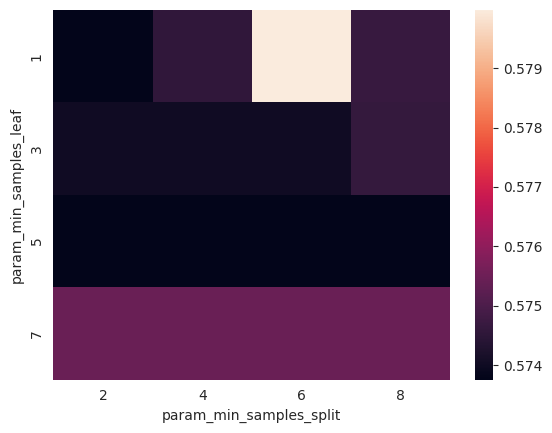

In [ ]:
dt = pd.DataFrame(grid3.cv_results_)

table = pd.pivot_table(dt, values='mean_test_score', index='param_min_samples_leaf',
                       columns='param_min_samples_split')

sns.heatmap(table)

In [ ]:
grid3.best_score_

np.float64(0.579978000424277)

Grid 4: Selecting class weight

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid4 = {
    'class_weight': [{0:1, 1:1}, {0:1, 1:2}, {0:1, 1:3}],
    'max_features': ['sqrt'],
    'n_estimators': [1000],
    'criterion': ['entropy'],
    'max_depth': [10],
    'min_samples_leaf': [1],
    'min_samples_split': [8]
}

rf_model = RandomForestClassifier(random_state=42)
grid4 = GridSearchCV(estimator=rf_model, param_grid=param_grid4,
                     n_jobs=-1, cv=3, verbose=1, scoring='f1')
grid4.fit(train_x, train_y)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 2},
                                          {0: 1, 1: 3}],
                         'criterion': ['entropy'], 'max_depth': [10],
                         'max_features': ['sqrt'], 'min_samples_leaf': [1],
                         'min_samples_split': [8], 'n_estimators': [1000]},
             scoring='f1', verbose=1)

In [ ]:
grid4.best_estimator_

RandomForestClassifier(class_weight={0: 1, 1: 3}, criterion='entropy',
                       max_depth=10, min_samples_split=8, n_estimators=1000,
                       random_state=42)

<Axes: ylabel='param_class_weight'>

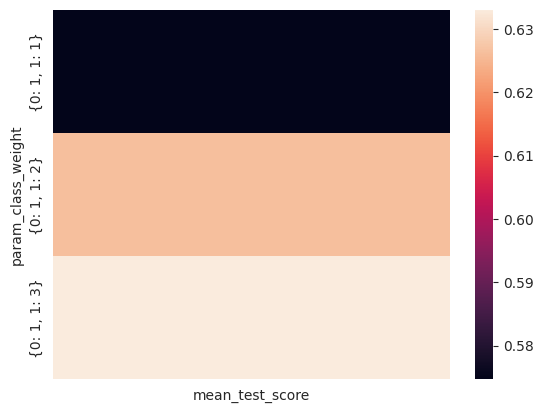

In [ ]:
dt = pd.DataFrame(grid4.cv_results_)
dt.param_class_weight = dt.param_class_weight.astype(str)
table = pd.pivot_table(dt, values='mean_test_score', index='param_class_weight')

sns.heatmap(table)

In [ ]:
grid4.best_score_

np.float64(0.6330431043479453)

**Final Model**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    bootstrap=True,
    ccp_alpha=0.0,
    class_weight={0: 1, 1: 2},
    criterion='entropy',
    max_depth=10,
    max_features='sqrt',
    max_leaf_nodes=None,
    max_samples=None,
    min_impurity_decrease=0.0,
    min_samples_leaf=1,
    min_samples_split=8,
    min_weight_fraction_leaf=0.0,
    n_estimators=1000,
    n_jobs=-1,
    oob_score=False,
    random_state=42,
    verbose=0,
    warm_start=False
)

model.fit(train_x, train_y)
print("Model trained successfully!")

Model trained successfully!


RandomForestClassifier(class_weight={0: 1, 1: 2}, criterion='entropy',
                       max_depth=10, min_samples_split=8, n_estimators=1000,
                       n_jobs=-1, random_state=42)

 Classification report : 
               precision    recall  f1-score   support

           0       0.87      0.84      0.85      1035
           1       0.59      0.66      0.62       374

    accuracy                           0.79      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.79      0.79      1409

Accuracy   Score :  0.7877927608232789
Area under curve :  0.8483143455010462 



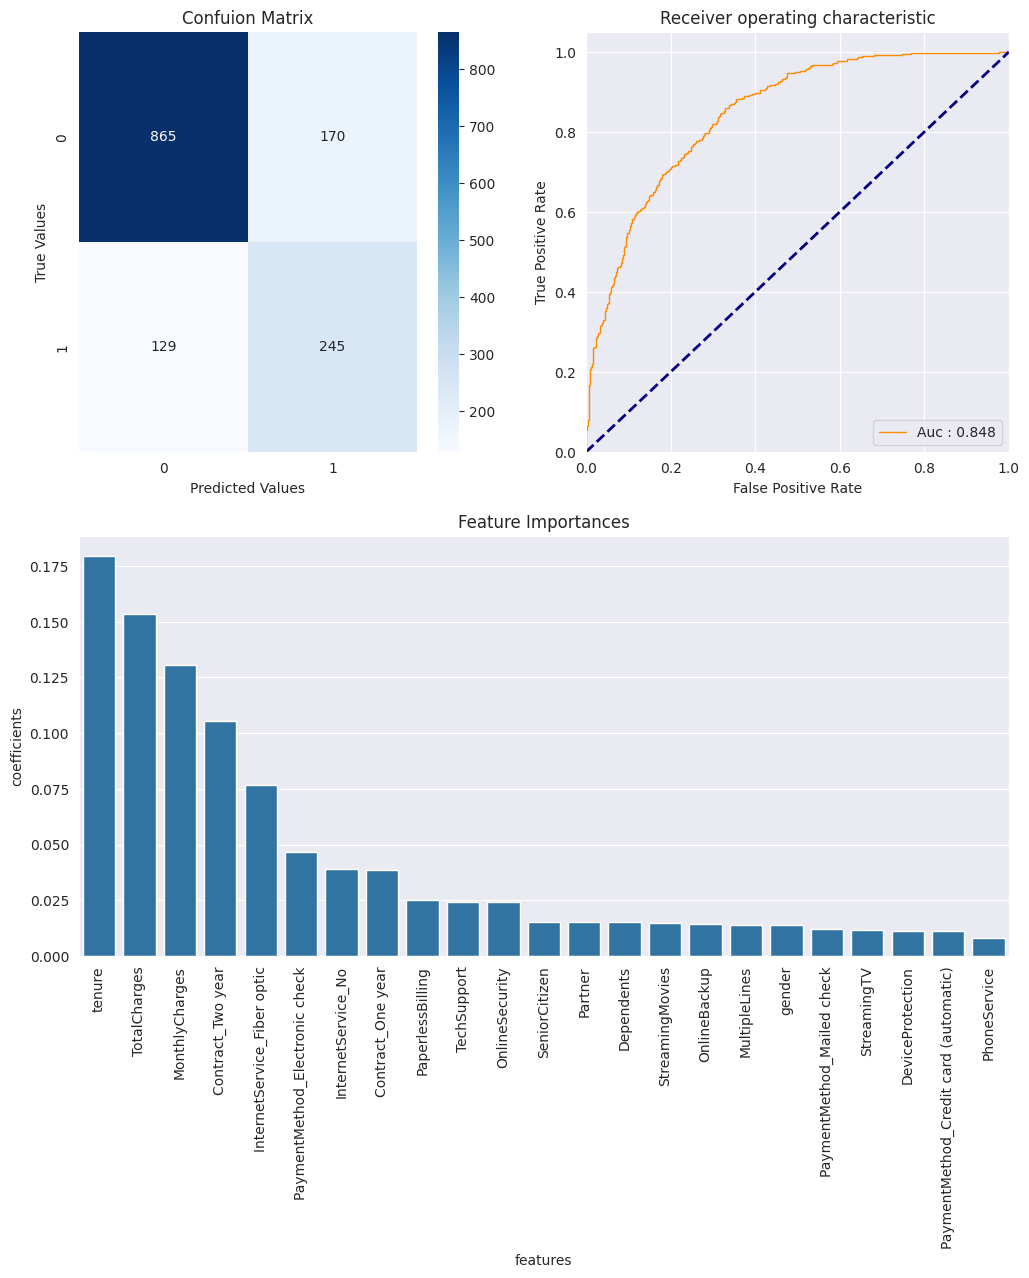

In [ ]:
churn_prediction(model, train_x, train_y, test_x, test_y, x,"features")

In [ ]:
train_scores = cross_val_score(model, train_x, train_y, cv = 5, scoring='f1')
train_scores

array([0.59815951, 0.66452648, 0.62341772, 0.58096828, 0.63622047])

In [ ]:
np.mean(train_scores)

np.float64(0.6206584936762072)

**Saving model**

In [ ]:
import pickle
pickle.dump(model, open('model.pkl','wb'))

**Explaining the model**

In [ ]:
!pip install eli5 pdpbox

In [99]:
import eli5
from eli5.sklearn import PermutationImportance

from pdpbox import pdp, info_plots

In [ ]:
perm = PermutationImportance(model, random_state=1).fit(test_x, test_y)
eli5.show_weights(perm, feature_names = test_x.columns.tolist())

Weight,Feature
0.0185 ± 0.0073,InternetService_Fiber optic
0.0050 ± 0.0079,InternetService_No
0.0050 ± 0.0105,Contract_Two year
0.0045 ± 0.0127,Contract_One year
0.0034 ± 0.0040,OnlineSecurity
0.0023 ± 0.0077,PaymentMethod_Electronic check
0.0023 ± 0.0093,tenure
0.0016 ± 0.0011,OnlineBackup
0.0016 ± 0.0096,PaperlessBilling
0.0011 ± 0.0083,MonthlyCharges


Internet Service: Fiber Optic

In [ ]:
from pdpbox import pdp
import matplotlib.pyplot as plt

pdp_p = pdp.PDPIsolate(
    model=model,
    df=test_x,
    model_features=test_x.columns.tolist(),
    feature='InternetService_Fiber optic',
    feature_name='InternetService_Fiber optic'
)

pdp_p.plot()
plt.show()

obtain pred_func from the provided model.


  0%|          | 0/2 [00:00<?, ?it/s]

Payment Method: Mailed Check

In [ ]:
import pandas as pd
print(type(train_x))
print(type(test_x))
print(train_x.columns.tolist() if isinstance(train_x, pd.DataFrame) else "train_x is numpy array - no column names")
print(test_x.columns.tolist() if isinstance(test_x, pd.DataFrame) else "test_x is numpy array - no column names")

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'x']


In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay

# Retrain model using the correct DataFrame
model = RandomForestClassifier(
    criterion='entropy',
    max_depth=10,
    max_features='sqrt',
    class_weight={0: 1, 1: 2},
    min_samples_leaf=1,
    min_samples_split=8,
    n_estimators=100,  # reduced for speed
    random_state=42
)
model.fit(train_x, train_y)
print("Model trained on columns:", train_x.columns.tolist()[:5], "...")
print("Feature exists:", 'PaymentMethod_Mailed check' in train_x.columns)

Model trained on columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure'] ...
Feature exists: True


Monthly Charges

Train columns: ['gender', 'SeniorCitizen', 'Partner'] ...
MonthlyCharges in train_x: True


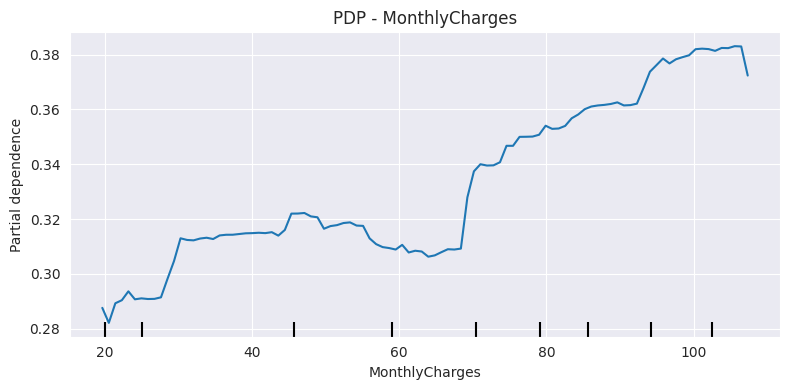

In [100]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay

# Retrain model with correct data
model = RandomForestClassifier(
    criterion='entropy',
    max_depth=10,
    max_features='sqrt',
    class_weight={0: 1, 1: 2},
    min_samples_leaf=1,
    min_samples_split=8,
    n_estimators=100,
    random_state=42
)
model.fit(train_x, train_y)

# Verify
print("Train columns:", train_x.columns[:3].tolist(), "...")
print("MonthlyCharges in train_x:", 'MonthlyCharges' in train_x.columns)

# PDP
fig, ax = plt.subplots(figsize=(8, 4))
PartialDependenceDisplay.from_estimator(
    model, train_x,
    features=['MonthlyCharges'],
    ax=ax
)
plt.title('PDP - MonthlyCharges')
plt.tight_layout()
plt.show()

Total Charges

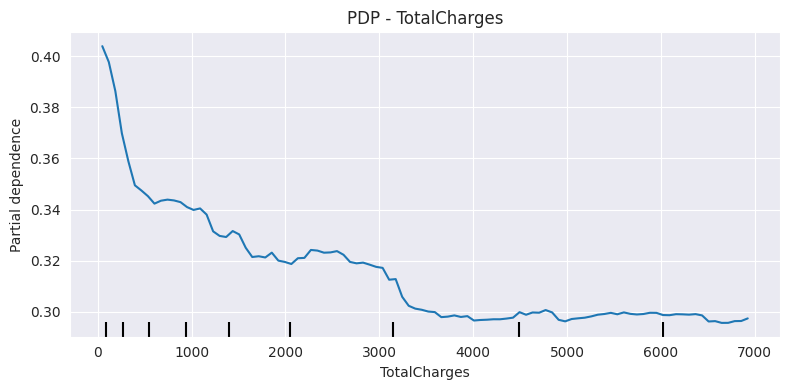

In [84]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(8, 4))
PartialDependenceDisplay.from_estimator(
    model, train_x,
    features=['TotalCharges'],
    ax=ax
)
plt.title('PDP - TotalCharges')
plt.tight_layout()
plt.show()

Contract - Two years

In [101]:
train_x_plot = train_x.copy()
bool_cols = train_x_plot.select_dtypes(include='bool').columns
train_x_plot[bool_cols] = train_x_plot[bool_cols].astype(int)
print("Boolean columns converted:", bool_cols.tolist())

Boolean columns converted: ['InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [105]:
# import matplotlib.pyplot as plt
# from sklearn.inspection import PartialDependenceDisplay
# from sklearn.ensemble import RandomForestClassifier
# import pandas as pd

# # Convert boolean columns to int
# train_x_plot = train_x.copy()
# bool_cols = train_x_plot.select_dtypes(include='bool').columns
# train_x_plot[bool_cols] = train_x_plot[bool_cols].astype(int)

# # Retrain model on converted data
# model = RandomForestClassifier(
#     criterion='entropy',
#     max_depth=10,
#     max_features='sqrt',
#     class_weight={0: 1, 1: 2},
#     min_samples_leaf=1,
#     min_samples_split=8,
#     n_estimators=100,
#     random_state=42
# )
# model.fit(train_x_plot, train_y)
# print("Model retrained successfully!")

# # PDP plot
# fig, ax = plt.subplots(figsize=(8, 4))
# PartialDependenceDisplay.from_estimator(
#     model, train_x_plot,
#     features=['Contract_Two year'],
#     ax=ax
# )
# plt.title('PDP - Contract Two year')
# plt.tight_layout()
# plt.show()

print("Skipping PDP for Contract_Two year - binary column not suitable for PDP")

Skipping PDP for Contract_Two year - binary column not suitable for PDP


Tenure

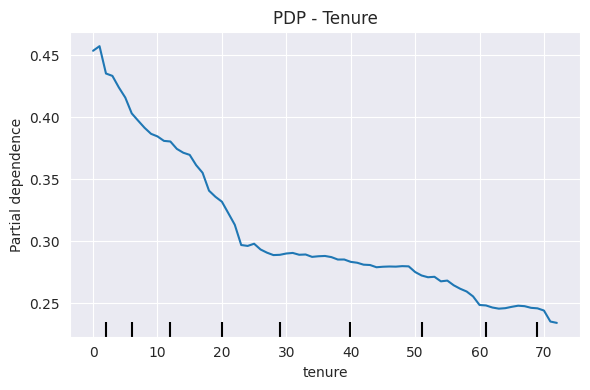

In [108]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(6, 4))
PartialDependenceDisplay.from_estimator(
    model, train_x_plot,
    features=['tenure'],
    ax=ax
)
plt.title('PDP - Tenure')
plt.tight_layout()
plt.show()

Shap Values

In [109]:
import shap
shap.initjs()

import joblib

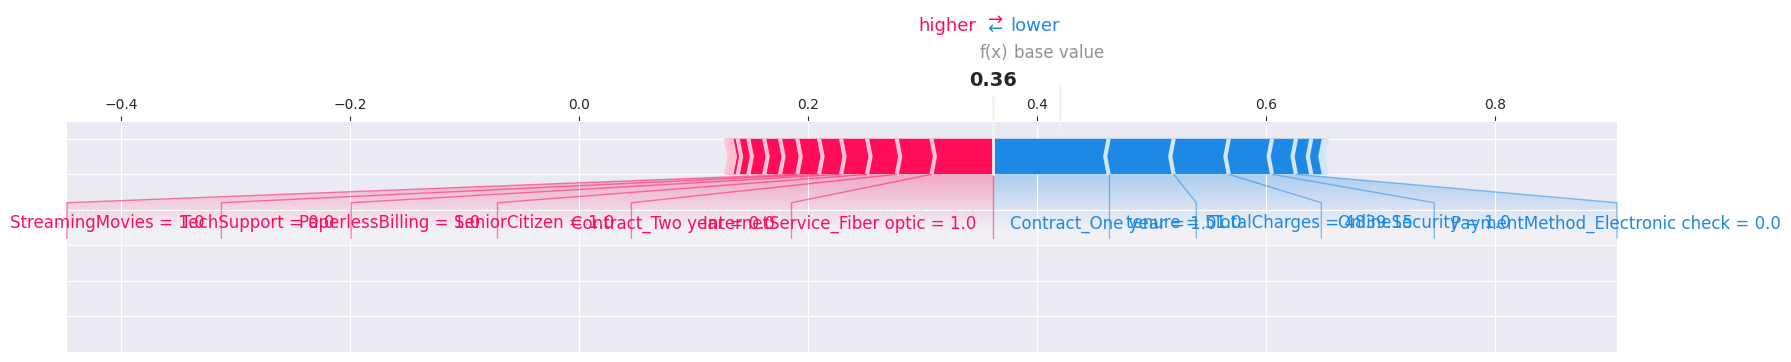

In [118]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# shap_values shape is (1, 23, 2) - use [..., 1] for class 1 (churn)
shap.plots.force(
    explainer.expected_value[1],
    shap_values[0, :, 1],
    single_row.iloc[0],
    matplotlib=True
)
plt.show()

In [119]:
# Saving Explainer
ex_filename = 'explainer.bz2'
joblib.dump(explainer, filename=ex_filename, compress=('bz2', 9))

['explainer.bz2']

Gauge Chart

In [122]:
from matplotlib.patches import Circle, Wedge, Rectangle

def degree_range(n):
    start = np.linspace(0,180,n+1, endpoint=True)[0:-1]
    end = np.linspace(0,180,n+1, endpoint=True)[1::]
    mid_points = start + ((end-start)/2.)
    return np.c_[start, end], mid_points

def rot_text(ang):
    rotation = np.degrees(np.radians(ang) * np.pi / np.pi - np.radians(90))
    return rotation

def gauge(labels=['LOW','MEDIUM','HIGH','EXTREME'], \
          colors=['#007A00','#0063BF','#FFCC00','#ED1C24'], Probability=1, fname=False):

    N = len(labels)
    colors = colors[::-1]

    """
    begins the plotting
    """

    fig, ax = plt.subplots()

    ang_range, mid_points = degree_range(4)

    labels = labels[::-1]

    """
    plots the sectors and the arcs
    """
    patches = []
    for ang, c in zip(ang_range, colors):
        # sectors
        patches.append(Wedge((0.,0.), .4, *ang, facecolor='w', lw=2))
        # arcs
        patches.append(Wedge((0.,0.), .4, *ang, width=0.10, facecolor=c, lw=2, alpha=0.5))

    [ax.add_patch(p) for p in patches]


    """
    set the labels (e.g. 'LOW','MEDIUM',...)
    """

    for mid, lab in zip(mid_points, labels):

        ax.text(0.35 * np.cos(np.radians(mid)), 0.35 * np.sin(np.radians(mid)), lab, \
            horizontalalignment='center', verticalalignment='center', fontsize=14, \
            fontweight='bold', rotation = rot_text(mid))

    """
    set the bottom banner and the title
    """
    r = Rectangle((-0.4,-0.1),0.8,0.1, facecolor='w', lw=2)
    ax.add_patch(r)

    ax.text(0, -0.05, 'Churn Probability ' + np.round(Probability,2).astype(str), horizontalalignment='center', \
         verticalalignment='center', fontsize=22, fontweight='bold')

    """
    plots the arrow now
    """

    pos = (1-Probability)*180
    ax.arrow(0, 0, 0.225 * np.cos(np.radians(pos)), 0.225 * np.sin(np.radians(pos)), \
                 width=0.04, head_width=0.09, head_length=0.1, fc='k', ec='k')

    ax.add_patch(Circle((0, 0), radius=0.02, facecolor='k'))
    ax.add_patch(Circle((0, 0), radius=0.01, facecolor='w', zorder=11))

    """
    removes frame and ticks, and makes axis equal and tight
    """

    ax.set_frame_on(False)
    ax.axes.set_xticks([])
    ax.axes.set_yticks([])
    ax.axis('equal')
    plt.tight_layout()
    if fname:
        fig.savefig(fname, dpi=200)

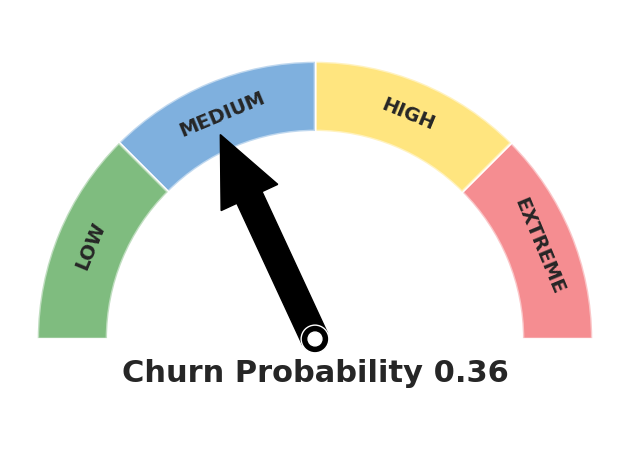

In [123]:
gauge(Probability=model.predict_proba(test_x.iloc[0:1])[0,1])

**Final Features**

In [124]:
test_x.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'InternetService_Fiber optic', 'InternetService_No',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')